### POC ML for Futures Trading


In [35]:
# Load API key from .env file
from dotenv import load_dotenv
import os

load_dotenv()  # Load environment variables from .env file
api_key = os.environ.get('POLYGON_API_KEY')

if api_key:
    print(f"API key loaded successfully (length: {len(api_key)} chars)")
else:
    print("POLYGON_API_KEY not found in .env file!")
    print("Create a .env file in the trading_brains folder with:")
    print("POLYGON_API_KEY=your-api-key-here")

API key loaded successfully (length: 32 chars)


In [56]:
# =============================================================================
# Data Import from Polygon.io (Massive) - 1-Minute Stock Data
# =============================================================================
import requests
import pandas as pd
from datetime import datetime, timedelta
import time

# Load API key from environment

def fetch_polygon_1min_data(symbol: str, start_date: str, end_date: str, api_key: str) -> pd.DataFrame:
    """
    Fetch 1-minute OHLCV data from Polygon.io
    
    Args:
        symbol: Stock ticker symbol (e.g., 'SPY', 'QQQ', 'IWM')
        start_date: Start date in 'YYYY-MM-DD' format
        end_date: End date in 'YYYY-MM-DD' format
        api_key: Polygon.io API key
    
    Returns:
        DataFrame with columns: timestamp, open, high, low, close, volume, vwap
    """
    all_data = []
    multiplier = 1
    timespan = "minute"
    
    url = f"https://api.polygon.io/v2/aggs/ticker/{symbol}/range/{multiplier}/{timespan}/{start_date}/{end_date}"
    
    params = {
        "adjusted": "true",
        "sort": "asc",
        "limit": 50000,
        "apiKey": api_key
    }
    
    print(f"Fetching {symbol} data from {start_date} to {end_date}...")
    
    while url:
        response = requests.get(url, params=params)
        
        if response.status_code != 200:
            print(f"❌ Error: {response.status_code} - {response.text}")
            break
            
        data = response.json()
        
        if data.get("results"):
            all_data.extend(data["results"])
            print(f"  Fetched {len(data['results'])} bars (total: {len(all_data)})")
        
        # Handle pagination
        url = data.get("next_url")
        if url:
            params = {"apiKey": api_key}
            time.sleep(0.15)  # Rate limiting
    
    if not all_data:
        print("❌ No data received")
        return pd.DataFrame()
    
    # Convert to DataFrame
    df = pd.DataFrame(all_data)
    
    # Rename columns to standard format
    df = df.rename(columns={
        "t": "timestamp",
        "o": "open",
        "h": "high",
        "l": "low",
        "c": "close",
        "v": "volume",
        "vw": "vwap",
        "n": "num_trades"
    })
    
    # Convert timestamp from milliseconds to datetime
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
    df = df.set_index("timestamp")
    
    # Select relevant columns
    cols = ["open", "high", "low", "close", "volume"]
    if "vwap" in df.columns:
        cols.append("vwap")
    
    df = df[cols]
    
    print(f"✅ Loaded {len(df)} 1-minute bars for {symbol}")
    print(f"   Date range: {df.index.min()} to {df.index.max()}")
    
    return df

# Example: Fetch SPY (S&P 500 ETF) as a proxy for index
# Polygon free tier: 2 years of historical data
# Adjust dates as needed
end_date = datetime.now().strftime("%Y-%m-%d")
start_date = (datetime.now() - timedelta(days=180)).strftime("%Y-%m-%d")  # Last 30 days

# Uncomment to fetch data:
df = fetch_polygon_1min_data("SPY", start_date, end_date, api_key)

Fetching SPY data from 2025-08-03 to 2026-01-30...
  Fetched 50000 bars (total: 50000)
  Fetched 50000 bars (total: 100000)
  Fetched 6788 bars (total: 106788)
✅ Loaded 106788 1-minute bars for SPY
   Date range: 2025-08-04 08:00:00 to 2026-01-30 00:59:00


In [57]:
df.head()

,open,high,low,close,volume,vwap
timestamp,,,,,,
2025-08-04 08:00:00,624.10,625.25,624.10,625.05,21639.0,624.9551
2025-08-04 08:01:00,625.05,625.06,625.00,625.00,5290.0,625.0262
2025-08-04 08:02:00,625.04,625.12,625.04,625.10,2696.0,625.0874
2025-08-04 08:03:00,625.11,625.27,625.11,625.27,6149.0,625.1814
2025-08-04 08:04:00,625.27,625.30,625.25,625.26,5806.0,625.2705


# Feature Engineering

- Creation of common metrics for time-series
- RSI, MACD, Bollinger Mavg, ATR, Stochastic-K, Return 1, Return 5, Rolling Average 30, 60, 90, 120, Volatility

In [59]:
# =============================================================================
# Data Preparation - Standardize column names and validate data
# =============================================================================

# Standardize column names to capitalized format (Open, High, Low, Close, Volume)
df.columns = df.columns.str.capitalize()

# Display data info
print("=" * 60)
print("DATA SUMMARY")
print("=" * 60)
print(f"\n📊 DataFrame shape: {df.shape}")
print(f"📅 Date range: {df.index.min()} to {df.index.max()}")
print(f"🕐 Frequency: 1-minute bars")
print(f"\n📋 Columns: {list(df.columns)}")
print(f"\n🔍 Missing values per column:")
print(df.isnull().sum())



DATA SUMMARY

📊 DataFrame shape: (106788, 6)
📅 Date range: 2025-08-04 08:00:00 to 2026-01-30 00:59:00
🕐 Frequency: 1-minute bars

📋 Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Vwap']

🔍 Missing values per column:
Open      0
High      0
Low       0
Close     0
Volume    0
Vwap      0
dtype: int64


In [60]:
df.head(20)

,Open,High,Low,Close,Volume,Vwap
timestamp,,,,,,
2025-08-04 08:00:00,624.10,625.25,624.10,625.05,21639.0,624.9551
2025-08-04 08:01:00,625.05,625.06,625.00,625.00,5290.0,625.0262
2025-08-04 08:02:00,625.04,625.12,625.04,625.10,2696.0,625.0874
2025-08-04 08:03:00,625.11,625.27,625.11,625.27,6149.0,625.1814
2025-08-04 08:04:00,625.27,625.30,625.25,625.26,5806.0,625.2705
2025-08-04 08:05:00,625.11,625.17,625.11,625.17,1207.0,625.1386
2025-08-04 08:06:00,625.04,625.12,625.04,625.12,2180.0,625.1071
2025-08-04 08:07:00,625.11,625.20,625.11,625.20,1602.0,625.1410
2025-08-04 08:09:00,625.19,625.24,625.19,625.24,762.0,625.2652


In [61]:
# =============================================================================
# FEATURE ENGINEERING - Technical Indicators for 1-Minute Data
# =============================================================================
import numpy as np

def calculate_rsi(prices: pd.Series, period: int = 14) -> pd.Series:
    """Calculate Relative Strength Index"""
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def calculate_macd(prices: pd.Series, fast: int = 12, slow: int = 26, signal: int = 9):
    """Calculate MACD, Signal line, and Histogram"""
    ema_fast = prices.ewm(span=fast, adjust=False).mean()
    ema_slow = prices.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    macd_signal = macd.ewm(span=signal, adjust=False).mean()
    macd_hist = macd - macd_signal
    return macd, macd_signal, macd_hist

def calculate_bollinger_bands(prices: pd.Series, period: int = 20, std_dev: float = 2.0):
    """Calculate Bollinger Bands"""
    middle = prices.rolling(window=period).mean()
    std = prices.rolling(window=period).std()
    upper = middle + (std * std_dev)
    lower = middle - (std * std_dev)
    return middle, upper, lower

def calculate_atr(high: pd.Series, low: pd.Series, close: pd.Series, period: int = 14) -> pd.Series:
    """Calculate Average True Range"""
    tr1 = high - low
    tr2 = abs(high - close.shift())
    tr3 = abs(low - close.shift())
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    return tr.rolling(window=period).mean()

def calculate_stochastic(high: pd.Series, low: pd.Series, close: pd.Series, period: int = 14) -> pd.Series:
    """Calculate Stochastic Oscillator %K"""
    lowest_low = low.rolling(window=period).min()
    highest_high = high.rolling(window=period).max()
    return 100 * (close - lowest_low) / (highest_high - lowest_low)

# Apply feature engineering to df
print("=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

# OHLC Standard Deviation (intraday volatility measure)
df['OHLC_Std'] = df[['Open', 'High', 'Low', 'Close']].std(axis=1)

# RSI
df['RSI'] = calculate_rsi(df['Close'], period=14)

# MACD
df['MACD'], df['MACD_Signal'], df['MACD_Hist'] = calculate_macd(df['Close'])

# Bollinger Bands
df['BB_Middle'], df['BB_Upper'], df['BB_Lower'] = calculate_bollinger_bands(df['Close'], period=20)

# ATR (Average True Range)
df['ATR'] = calculate_atr(df['High'], df['Low'], df['Close'], period=14)

# Stochastic Oscillator
df['Stochastic_K'] = calculate_stochastic(df['High'], df['Low'], df['Close'], period=14)

# Returns (1-bar and 5-bar)
df['Return_1'] = df['Close'].pct_change(1)
df['Return_5'] = df['Close'].pct_change(5)

# Simple Moving Averages (adjusted for 1-minute data)
df['SMA_30'] = df['Close'].rolling(window=30).mean()    # 30-minute SMA
df['SMA_60'] = df['Close'].rolling(window=60).mean()    # 1-hour SMA
df['SMA_120'] = df['Close'].rolling(window=120).mean()  # 2-hour SMA
df['SMA_390'] = df['Close'].rolling(window=390).mean()  # ~1 trading day SMA

# Volatility (20-bar rolling std of returns)
df['Volatility_20'] = df['Return_1'].rolling(window=20).std()

# Volume-based features
df['Volume_SMA_20'] = df['Volume'].rolling(window=20).mean()
df['Volume_Ratio'] = df['Volume'] / df['Volume_SMA_20']

# Price position within day's range
df['Price_Position'] = (df['Close'] - df['Low']) / (df['High'] - df['Low'] + 1e-10)

print("\n✅ Feature engineering complete!")
print(f"\n📊 DataFrame shape: {df.shape}")
print(f"\n📋 New columns added:")
new_cols = [col for col in df.columns if col not in ['Open', 'High', 'Low', 'Close', 'Volume', 'Vwap']]
for col in new_cols:
    print(f"  - {col}")

print(f"\n🔍 Missing values (from rolling calculations):")
print(df.isnull().sum().tail(10))

FEATURE ENGINEERING

✅ Feature engineering complete!

📊 DataFrame shape: (106788, 26)

📋 New columns added:
  - OHLC_Std
  - RSI
  - MACD
  - MACD_Signal
  - MACD_Hist
  - BB_Middle
  - BB_Upper
  - BB_Lower
  - ATR
  - Stochastic_K
  - Return_1
  - Return_5
  - SMA_30
  - SMA_60
  - SMA_120
  - SMA_390
  - Volatility_20
  - Volume_SMA_20
  - Volume_Ratio
  - Price_Position

🔍 Missing values (from rolling calculations):
Return_1            1
Return_5            5
SMA_30             29
SMA_60             59
SMA_120           119
SMA_390           389
Volatility_20      20
Volume_SMA_20      19
Volume_Ratio       19
Price_Position      0
dtype: int64


In [62]:
# =============================================================================
# LAGGED FEATURES - Capture temporal dependencies
# =============================================================================

print("=" * 60)
print("CREATING LAGGED FEATURES")
print("=" * 60)

# Define lag periods (in minutes for 1-min data)
lag_periods = [1, 5, 15, 30, 60]  # 1min, 5min, 15min, 30min, 1hour

# Store original column count
original_cols = len(df.columns)

# ===== Price Lags =====
print("\n📊 Adding price lags...")
for lag in lag_periods:
    df[f'Close_lag_{lag}'] = df['Close'].shift(lag)
    df[f'Open_lag_{lag}'] = df['Open'].shift(lag)

# ===== Return Lags =====
print("📈 Adding return lags...")
df['Return'] = df['Close'].pct_change()
for lag in lag_periods:
    df[f'Return_lag_{lag}'] = df['Return'].shift(lag)

# ===== Volatility Lags (rolling std of returns) =====
print("📉 Adding volatility lags...")
df['Volatility_5'] = df['Return'].rolling(window=5).std()
df['Volatility_15'] = df['Return'].rolling(window=15).std()
df['Volatility_30'] = df['Return'].rolling(window=30).std()

for lag in [1, 5, 15]:
    df[f'Volatility_5_lag_{lag}'] = df['Volatility_5'].shift(lag)

# ===== Volume Lags =====
print("📦 Adding volume lags...")
for lag in lag_periods[:3]:  # 1, 5, 15 min lags
    df[f'Volume_lag_{lag}'] = df['Volume'].shift(lag)

# Volume change
df['Volume_change'] = df['Volume'].pct_change()
df['Volume_change_lag_1'] = df['Volume_change'].shift(1)

# ===== Price Momentum =====
print("🚀 Adding momentum features...")
df['Momentum_5'] = df['Close'] - df['Close'].shift(5)
df['Momentum_15'] = df['Close'] - df['Close'].shift(15)
df['Momentum_30'] = df['Close'] - df['Close'].shift(30)

# ===== Rolling Statistics Lags =====
print("📐 Adding rolling statistics lags...")
df['High_Low_Range'] = df['High'] - df['Low']
df['High_Low_Range_lag_1'] = df['High_Low_Range'].shift(1)
df['High_Low_Range_lag_5'] = df['High_Low_Range'].shift(5)

# ===== Relative Strength (price position) =====
df['Price_vs_SMA_30'] = df['Close'] / df['Close'].rolling(30).mean() - 1
df['Price_vs_SMA_60'] = df['Close'] / df['Close'].rolling(60).mean() - 1

# ===== Summary =====
new_cols = len(df.columns) - original_cols
print(f"\n✅ Created {new_cols} new lagged features")
print(f"   Total columns: {len(df.columns)}")

# Show new columns
lagged_cols = [col for col in df.columns if 'lag' in col.lower() or 'momentum' in col.lower()]
print(f"\n📋 Lagged/Momentum features ({len(lagged_cols)}):")
for col in lagged_cols:
    print(f"   - {col}")

CREATING LAGGED FEATURES

📊 Adding price lags...
📈 Adding return lags...
📉 Adding volatility lags...
📦 Adding volume lags...
🚀 Adding momentum features...
📐 Adding rolling statistics lags...

✅ Created 35 new lagged features
   Total columns: 61

📋 Lagged/Momentum features (27):
   - Close_lag_1
   - Open_lag_1
   - Close_lag_5
   - Open_lag_5
   - Close_lag_15
   - Open_lag_15
   - Close_lag_30
   - Open_lag_30
   - Close_lag_60
   - Open_lag_60
   - Return_lag_1
   - Return_lag_5
   - Return_lag_15
   - Return_lag_30
   - Return_lag_60
   - Volatility_5_lag_1
   - Volatility_5_lag_5
   - Volatility_5_lag_15
   - Volume_lag_1
   - Volume_lag_5
   - Volume_lag_15
   - Volume_change_lag_1
   - Momentum_5
   - Momentum_15
   - Momentum_30
   - High_Low_Range_lag_1
   - High_Low_Range_lag_5


In [63]:
# Display feature statistics
print("=" * 60)
print("FEATURE STATISTICS")
print("=" * 60)
print(df.describe().round(4))

FEATURE STATISTICS
              Open         High          Low        Close        Volume  \
count  106788.0000  106788.0000  106788.0000  106788.0000  1.067880e+05   
mean      669.5763     669.6602     669.4906     669.5762  8.652706e+04   
std        17.8747      17.8735      17.8759      17.8744  2.042026e+05   
min       624.1000     624.9200     621.7200     624.8600  4.000000e+01   
25%       658.7100     658.8300     658.5700     658.7098  1.162000e+03   
50%       672.0000     672.0600     671.9400     672.0000  1.650500e+04   
75%       684.4700     684.5400     684.3800     684.4700  1.153558e+05   
max       698.3100     698.3500     698.3000     698.3300  8.513468e+06   

              Vwap     OHLC_Std          RSI         MACD  MACD_Signal  ...  \
count  106788.0000  106788.0000  106775.0000  106788.0000  106788.0000  ...   
mean      669.5685       0.0826      50.8089       0.0044       0.0044  ...   
std        17.8773       0.1135      16.2899       0.1984       0.18

# Data Analysis

In [64]:
# =============================================================================
# DATA CLEANING
# =============================================================================

print("=" * 60)
print("DATA CLEANING REPORT")
print("=" * 60)

# Check for missing values
missing_vals = df.isnull().sum()
missing_cols = missing_vals[missing_vals > 0]
print(f"\n📊 Missing values BEFORE cleaning:")
print(missing_cols)
print(f"\nTotal missing values: {missing_cols.sum()}")
print(f"Rows with any NaN: {df.isnull().any(axis=1).sum()} out of {len(df)}")

# For 1-minute data, we have many more rows, so we can afford to drop NaN rows
# from rolling calculations (they only affect the first N rows)
threshold = len(df) * 0.5  # Drop columns where >50% of data is missing

cols_to_drop = missing_vals[missing_vals > threshold].index.tolist()
if cols_to_drop:
    print(f"\n🗑️ Dropped columns with insufficient data: {cols_to_drop}")
    df = df.drop(columns=cols_to_drop)

# Drop rows with NaN values (from rolling calculations at the start)
rows_before = len(df)
df = df.dropna()
rows_after = len(df)

print(f"\n✅ After dropping NaN rows:")
print(f"   Rows dropped: {rows_before - rows_after}")
print(f"   Remaining rows: {rows_after}")
print(f"   Remaining missing values: {df.isnull().sum().sum()}")

# Check for infinite values
inf_count = np.isinf(df.select_dtypes(include=[np.number])).sum().sum()
print(f"\n♾️ Infinite values found: {inf_count}")
if inf_count > 0:
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    print(f"   Removed infinite values. New row count: {len(df)}")

# Check for duplicate indices
dup_count = df.index.duplicated().sum()
print(f"\n🔄 Duplicate indices: {dup_count}")
if dup_count > 0:
    df = df[~df.index.duplicated(keep='first')]

print("\n" + "=" * 60)
print("📈 CLEAN DATA SUMMARY")
print("=" * 60)
print(f"   Date range: {df.index.min()} to {df.index.max()}")
print(f"   Total rows: {len(df)}")
print(f"   Total features: {len(df.columns)}")
print(f"\n   Columns: {list(df.columns)}")

DATA CLEANING REPORT

📊 Missing values BEFORE cleaning:
RSI                      13
BB_Middle                19
BB_Upper                 19
BB_Lower                 19
ATR                      13
Stochastic_K             13
Return_1                  1
Return_5                  5
SMA_30                   29
SMA_60                   59
SMA_120                 119
SMA_390                 389
Volatility_20            20
Volume_SMA_20            19
Volume_Ratio             19
Close_lag_1               1
Open_lag_1                1
Close_lag_5               5
Open_lag_5                5
Close_lag_15             15
Open_lag_15              15
Close_lag_30             30
Open_lag_30              30
Close_lag_60             60
Open_lag_60              60
Return                    1
Return_lag_1              2
Return_lag_5              6
Return_lag_15            16
Return_lag_30            31
Return_lag_60            61
Volatility_5              5
Volatility_15            15
Volatility_30       

In [65]:
# =============================================================================
# CORRELATION ANALYSIS
# =============================================================================

print("=" * 60)
print("CORRELATION ANALYSIS")
print("=" * 60)

# Correlation with Close price
print("\n🎯 Correlation with Close price:")
corr_close = df.corr()['Close'].sort_values(ascending=False)
print(corr_close.round(3))

# Correlation with 1-bar Return
if 'Return_1' in df.columns:
    print("\n🎯 Correlation with 1-bar Return:")
    corr_return = df.corr()['Return_1'].sort_values(ascending=False)
    print(corr_return.round(3))

CORRELATION ANALYSIS

🎯 Correlation with Close price:
Close                  1.000
High                   1.000
Low                    1.000
Open                   1.000
Close_lag_1            1.000
                       ...  
Volatility_5_lag_1    -0.056
Volatility_5_lag_15   -0.056
Volatility_15         -0.063
Volatility_20         -0.064
Volatility_30         -0.066
Name: Close, Length: 61, dtype: float64

🎯 Correlation with 1-bar Return:
Return_1          1.000
Return            1.000
Return_5          0.443
Momentum_5        0.442
Price_Position    0.434
                  ...  
Return_lag_5     -0.008
Volume_Ratio     -0.009
High_Low_Range   -0.019
OHLC_Std         -0.024
Return_lag_1     -0.065
Name: Return_1, Length: 61, dtype: float64


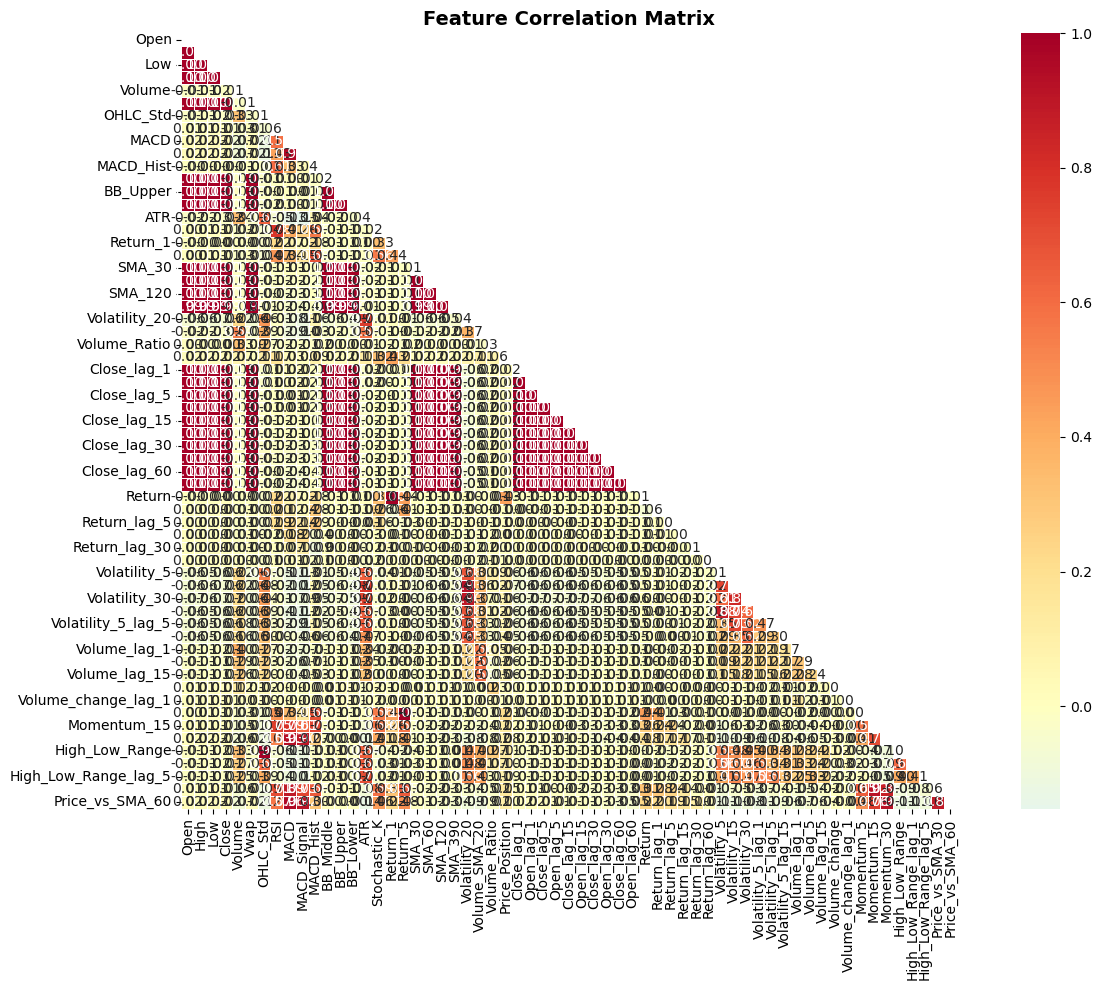

In [66]:
# =============================================================================
# CORRELATION HEATMAP
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))
correlation_matrix = df.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='RdYlBu_r', center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [67]:
# =============================================================================
# REMOVE HIGHLY CORRELATED FEATURES
# =============================================================================

def remove_highly_correlated(dataframe: pd.DataFrame, threshold: float = 0.65, protect_cols: list = None) -> pd.DataFrame:
    """Remove features that are highly correlated with each other
    
    Args:
        dataframe: Input DataFrame
        threshold: Correlation threshold above which to remove features
        protect_cols: List of columns to never drop (e.g., target variable)
    """
    if protect_cols is None:
        protect_cols = []
    
    corr_matrix = dataframe.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Find columns with correlation greater than threshold
    to_drop = set()
    for column in upper.columns:
        correlated = upper.index[upper[column] > threshold].tolist()
        if correlated:
            to_drop.update(correlated)
    
    # Remove protected columns from the drop list
    to_drop = to_drop - set(protect_cols)
    
    return dataframe.drop(columns=list(to_drop)), list(to_drop)

print("=" * 60)
print(f"REMOVING HIGHLY CORRELATED FEATURES (threshold = 0.65)")
print("=" * 60)

print(f"\nColumns BEFORE removal: {len(df.columns)}")
print(f"   {list(df.columns)}")

# Protect 'Close' from being dropped (it's our target variable)
df_reduced, dropped_cols = remove_highly_correlated(df, threshold=0.65, protect_cols=['Close'])

print(f"\n🗑️ Columns to remove (|r| > 0.65):")
for col in sorted(dropped_cols):
    print(f"   - {col}")

print(f"\n✅ Columns AFTER removal: {len(df_reduced.columns)}")
print(f"   {list(df_reduced.columns)}")

# Update df to the reduced version
df = df_reduced.copy()

print("\n" + "=" * 60)
print("UPDATED CORRELATION MATRIX (remaining features)")
print("=" * 60)
print(df.corr().round(2))

REMOVING HIGHLY CORRELATED FEATURES (threshold = 0.65)

Columns BEFORE removal: 61
   ['Open', 'High', 'Low', 'Close', 'Volume', 'Vwap', 'OHLC_Std', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'ATR', 'Stochastic_K', 'Return_1', 'Return_5', 'SMA_30', 'SMA_60', 'SMA_120', 'SMA_390', 'Volatility_20', 'Volume_SMA_20', 'Volume_Ratio', 'Price_Position', 'Close_lag_1', 'Open_lag_1', 'Close_lag_5', 'Open_lag_5', 'Close_lag_15', 'Open_lag_15', 'Close_lag_30', 'Open_lag_30', 'Close_lag_60', 'Open_lag_60', 'Return', 'Return_lag_1', 'Return_lag_5', 'Return_lag_15', 'Return_lag_30', 'Return_lag_60', 'Volatility_5', 'Volatility_15', 'Volatility_30', 'Volatility_5_lag_1', 'Volatility_5_lag_5', 'Volatility_5_lag_15', 'Volume_lag_1', 'Volume_lag_5', 'Volume_lag_15', 'Volume_change', 'Volume_change_lag_1', 'Momentum_5', 'Momentum_15', 'Momentum_30', 'High_Low_Range', 'High_Low_Range_lag_1', 'High_Low_Range_lag_5', 'Price_vs_SMA_30', 'Price_vs_SMA_60']

🗑️ Columns to r

In [68]:
# =============================================================================
# PREPARE FINAL DATASET WITH TARGET VARIABLE
# =============================================================================

# IMPORTANT: We need to preserve 'Close' as our target before feature reduction
# Get the Close column from the original cleaned data before correlation removal
# We'll use df_reduced (features without highly correlated ones) + Close from before

# First, let's rebuild df_model with the reduced features PLUS the Close column
# The Close column should come from the data BEFORE the correlation removal step

# Check what we have available
print("=" * 60)
print("BUILDING FINAL MODELING DATASET")
print("=" * 60)

# df_reduced has the non-correlated features but may not have Close
# We need to get Close from before the dropna/cleaning step

# Re-read the original df data (this requires re-running earlier cells)
# For now, let's work with what we have in the kernel

# Check if Close exists in df or df_reduced
print(f"\n📋 Available DataFrames:")
print(f"   df columns: {list(df.columns)}")
print(f"   df shape: {df.shape}")
print(f"   df_reduced columns: {list(df_reduced.columns)}")
print(f"   df_reduced shape: {df_reduced.shape}")

# If Close is not in df, we have a problem - need to re-run from feature engineering
if 'Close' not in df.columns and 'Close' not in df_reduced.columns:
    print("\n⚠️ 'Close' column is missing!")
    print("   Please re-run cells from Feature Engineering (cell 8) onwards")
    print("   This will rebuild the data pipeline with Close preserved")
else:
    # Build the modeling dataframe
    if 'Close' in df_reduced.columns:
        df_model = df_reduced.copy()
    else:
        # Get Close from df and merge with df_reduced
        df_model = df_reduced.copy()
        df_model['Close'] = df['Close']
    
    print(f"\n✅ df_model created:")
    print(f"   Shape: {df_model.shape}")
    print(f"   Columns: {list(df_model.columns)}")

BUILDING FINAL MODELING DATASET

📋 Available DataFrames:
   df columns: ['Close', 'Volume', 'Stochastic_K', 'Volume_SMA_20', 'Volume_Ratio', 'Price_Position', 'Open_lag_60', 'Return', 'Return_lag_1', 'Return_lag_5', 'Return_lag_15', 'Return_lag_30', 'Return_lag_60', 'Volatility_30', 'Volatility_5_lag_1', 'Volatility_5_lag_5', 'Volatility_5_lag_15', 'Volume_lag_1', 'Volume_lag_5', 'Volume_lag_15', 'Volume_change', 'Volume_change_lag_1', 'High_Low_Range', 'High_Low_Range_lag_1', 'High_Low_Range_lag_5', 'Price_vs_SMA_60']
   df shape: (106399, 26)
   df_reduced columns: ['Close', 'Volume', 'Stochastic_K', 'Volume_SMA_20', 'Volume_Ratio', 'Price_Position', 'Open_lag_60', 'Return', 'Return_lag_1', 'Return_lag_5', 'Return_lag_15', 'Return_lag_30', 'Return_lag_60', 'Volatility_30', 'Volatility_5_lag_1', 'Volatility_5_lag_5', 'Volatility_5_lag_15', 'Volume_lag_1', 'Volume_lag_5', 'Volume_lag_15', 'Volume_change', 'Volume_change_lag_1', 'High_Low_Range', 'High_Low_Range_lag_1', 'High_Low_Range_

In [69]:
# Display final dataframe
df

,Close,Volume,Stochastic_K,Volume_SMA_20,Volume_Ratio,Price_Position,Open_lag_60,Return,Return_lag_1,Return_lag_5,...,Volatility_5_lag_15,Volume_lag_1,Volume_lag_5,Volume_lag_15,Volume_change,Volume_change_lag_1,High_Low_Range,High_Low_Range_lag_1,High_Low_Range_lag_5,Price_vs_SMA_60
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-08-04 15:04:00,629.2600,119773.0,74.444444,191217.40,0.626371,0.311111,628.9300,-0.000270,0.000302,0.000175,...,0.000234,132648.0,124220.0,318192.0,-0.097061,-0.221924,0.2250,0.2600,0.1400,0.000312
2025-08-04 15:05:00,629.2600,128934.0,71.250000,188270.35,0.684834,0.790698,629.0400,0.000000,-0.000270,-0.000612,...,0.000551,119773.0,149585.0,197530.0,0.076486,-0.097061,0.2150,0.2250,0.4200,0.000307
2025-08-04 15:06:00,629.2100,87999.0,65.000000,182234.75,0.482888,0.317073,629.0800,-0.000079,0.000000,0.000374,...,0.000535,128934.0,156405.0,469632.0,-0.317488,0.076486,0.2050,0.2150,0.4300,0.000225
2025-08-04 15:07:00,629.2200,163565.0,66.250000,179345.40,0.912011,0.864407,629.0900,0.000016,-0.000079,0.000334,...,0.000564,87999.0,170482.0,209727.0,0.858714,-0.317488,0.2950,0.2050,0.3400,0.000232
2025-08-04 15:08:00,629.2400,131821.0,68.750000,176172.35,0.748250,0.400000,628.9000,0.000032,0.000016,0.000302,...,0.000614,163565.0,132648.0,172215.0,-0.194076,0.858714,0.2000,0.2950,0.2600,0.000247
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-30 00:55:00,692.7400,745.0,70.890563,994.45,0.749158,1.000000,693.8300,0.000130,-0.000159,-0.000115,...,0.000313,1168.0,176.0,300.0,-0.362158,2.156757,0.0100,0.0900,0.0000,-0.000564
2026-01-30 00:56:00,692.8000,3097.0,90.605627,1135.50,2.727433,0.000000,693.7590,0.000087,0.000130,-0.000303,...,0.000138,745.0,5548.0,1899.0,3.157047,-0.362158,0.0000,0.0100,0.2000,-0.000456
2026-01-30 00:57:00,692.7604,914.0,74.388112,1152.25,0.793231,0.000000,693.7283,-0.000057,0.000087,0.000289,...,0.000131,3097.0,438.0,562.0,-0.704876,3.157047,0.1172,0.0000,0.0300,-0.000490


# Training

In [12]:
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_lightning import Trainer


c:\Users\batzi\anaconda3\envs\trading_brains\Lib\site-packages\pytorch_forecasting\models\base\_base_model.py:30: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


## Model Training

With limited data (87 rows), we'll use models that work well with small datasets:
1. **Ridge Regression** - baseline linear model with regularization
2. **Random Forest** - ensemble method, handles non-linearity
3. **XGBoost** - gradient boosting, often best for tabular data

We'll use walk-forward validation (time series split) to avoid data leakage.

In [70]:
# =============================================================================
# DATA PREPARATION FOR MODELING
# =============================================================================
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

print("=" * 60)
print("DATA PREPARATION FOR MODELING")
print("=" * 60)

# Use df_model which should have features + Close
if 'df_model' not in dir() or df_model.shape[0] == 0:
    print("⚠️ df_model not found or empty. Attempting to rebuild...")
    # Fallback: try to use df if it has Close
    if 'Close' in df.columns and df.shape[0] > 0:
        df_model = df.copy()
        print(f"   Using df with {len(df_model)} rows")
    else:
        print("❌ ERROR: No valid data available!")
        print("   Please re-run cells from Feature Engineering onwards")
        raise ValueError("No data available for modeling")

# Ensure no NaN values
nan_count = df_model.isnull().sum().sum()
print(f"\n🔍 NaN values in df_model: {nan_count}")

if nan_count > 0:
    print(f"   Dropping {df_model.isnull().any(axis=1).sum()} rows with NaN values...")
    df_model = df_model.dropna()
    print(f"   Remaining rows: {len(df_model)}")

# Check for infinite values in numeric columns only
numeric_cols = df_model.select_dtypes(include=[np.number]).columns
inf_mask = np.isinf(df_model[numeric_cols]).any(axis=1)
if inf_mask.sum() > 0:
    print(f"   Dropping {inf_mask.sum()} rows with infinite values...")
    df_model = df_model[~inf_mask]

# Define features and target
feature_columns = [col for col in df_model.columns if col != 'Close']
X = df_model[feature_columns].astype(np.float64).values
y = df_model['Close'].astype(np.float64).values

# Final check
print(f"\n✅ Data ready for modeling:")
print(f"   Features: {feature_columns}")
print(f"   X shape: {X.shape}")
print(f"   y shape: {y.shape}")

if X.shape[0] == 0:
    raise ValueError("No samples available for training! Please re-run from Feature Engineering.")

# Time Series Cross-Validation setup
n_splits = min(5, X.shape[0] // 10)  # Ensure we have enough samples per split
n_splits = max(2, n_splits)  # At least 2 splits
tscv = TimeSeriesSplit(n_splits=n_splits)

print(f"\n📊 Time Series Cross-Validation:")
print(f"   Number of splits: {n_splits}")

for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
    print(f"   Split {i+1}: Train size={len(train_idx)}, Test size={len(test_idx)}")

DATA PREPARATION FOR MODELING

🔍 NaN values in df_model: 0

✅ Data ready for modeling:
   Features: ['Volume', 'Stochastic_K', 'Volume_SMA_20', 'Volume_Ratio', 'Price_Position', 'Open_lag_60', 'Return', 'Return_lag_1', 'Return_lag_5', 'Return_lag_15', 'Return_lag_30', 'Return_lag_60', 'Volatility_30', 'Volatility_5_lag_1', 'Volatility_5_lag_5', 'Volatility_5_lag_15', 'Volume_lag_1', 'Volume_lag_5', 'Volume_lag_15', 'Volume_change', 'Volume_change_lag_1', 'High_Low_Range', 'High_Low_Range_lag_1', 'High_Low_Range_lag_5', 'Price_vs_SMA_60']
   X shape: (106399, 25)
   y shape: (106399,)

📊 Time Series Cross-Validation:
   Number of splits: 5
   Split 1: Train size=17734, Test size=17733
   Split 2: Train size=35467, Test size=17733
   Split 3: Train size=53200, Test size=17733
   Split 4: Train size=70933, Test size=17733
   Split 5: Train size=88666, Test size=17733


In [71]:
# =============================================================================
# MODEL TRAINING WITH TIME SERIES CROSS-VALIDATION
# =============================================================================
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Try to import XGBoost, fall back to GradientBoosting if not available
try:
    from xgboost import XGBRegressor
    use_xgboost = True
except ImportError:
    print("⚠️ XGBoost not installed, using sklearn's GradientBoostingRegressor instead")
    use_xgboost = False

# Define models to compare
if use_xgboost:
    models = {
        'Ridge Regression': Ridge(alpha=1.0),
        'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
        'XGBoost': XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, verbosity=0)
    }
else:
    models = {
        'Ridge Regression': Ridge(alpha=1.0),
        'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
    }

# Store results
results = {name: {'rmse': [], 'mae': [], 'r2': []} for name in models.keys()}

print("=" * 60)
print("MODEL TRAINING WITH TIME SERIES CROSS-VALIDATION")
print("=" * 60)

# Scaler for features
scaler = StandardScaler()

for name, model in models.items():
    print(f"\n🔄 Training: {name}")
    
    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Scale features
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Train model
        model.fit(X_train_scaled, y_train)
        
        # Predict
        y_pred = model.predict(X_test_scaled)
        
        # Calculate metrics
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        results[name]['rmse'].append(rmse)
        results[name]['mae'].append(mae)
        results[name]['r2'].append(r2)
    
    avg_rmse = np.mean(results[name]['rmse'])
    avg_mae = np.mean(results[name]['mae'])
    avg_r2 = np.mean(results[name]['r2'])
    
    print(f"   Avg RMSE: ${avg_rmse:.4f}")
    print(f"   Avg MAE:  ${avg_mae:.4f}")
    print(f"   Avg R²:   {avg_r2:.4f}")

# Summary comparison
print("\n" + "=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)

summary_data = []
for name in models.keys():
    summary_data.append({
        'Model': name,
        'Avg RMSE': np.mean(results[name]['rmse']),
        'Std RMSE': np.std(results[name]['rmse']),
        'Avg MAE': np.mean(results[name]['mae']),
        'Avg R²': np.mean(results[name]['r2'])
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Best model
best_model_name = summary_df.loc[summary_df['Avg RMSE'].idxmin(), 'Model']
print(f"\n🏆 Best Model: {best_model_name}")

MODEL TRAINING WITH TIME SERIES CROSS-VALIDATION

🔄 Training: Ridge Regression
   Avg RMSE: $0.6708
   Avg MAE:  $0.4314
   Avg R²:   0.9878

🔄 Training: Random Forest
   Avg RMSE: $5.1614
   Avg MAE:  $3.9546
   Avg R²:   0.0529

🔄 Training: XGBoost
   Avg RMSE: $5.0445
   Avg MAE:  $3.8481
   Avg R²:   0.0729

MODEL COMPARISON SUMMARY
           Model  Avg RMSE  Std RMSE  Avg MAE   Avg R²
Ridge Regression  0.670762  0.133343 0.431374 0.987766
   Random Forest  5.161351  4.561563 3.954571 0.052882
         XGBoost  5.044536  4.574014 3.848146 0.072909

🏆 Best Model: Ridge Regression


FINAL MODEL EVALUATION (Ridge Regression)

📊 Holdout Set Performance (last 5000 minutes):
   RMSE: $0.5645
   MAE:  $0.3748
   R²:   0.9713


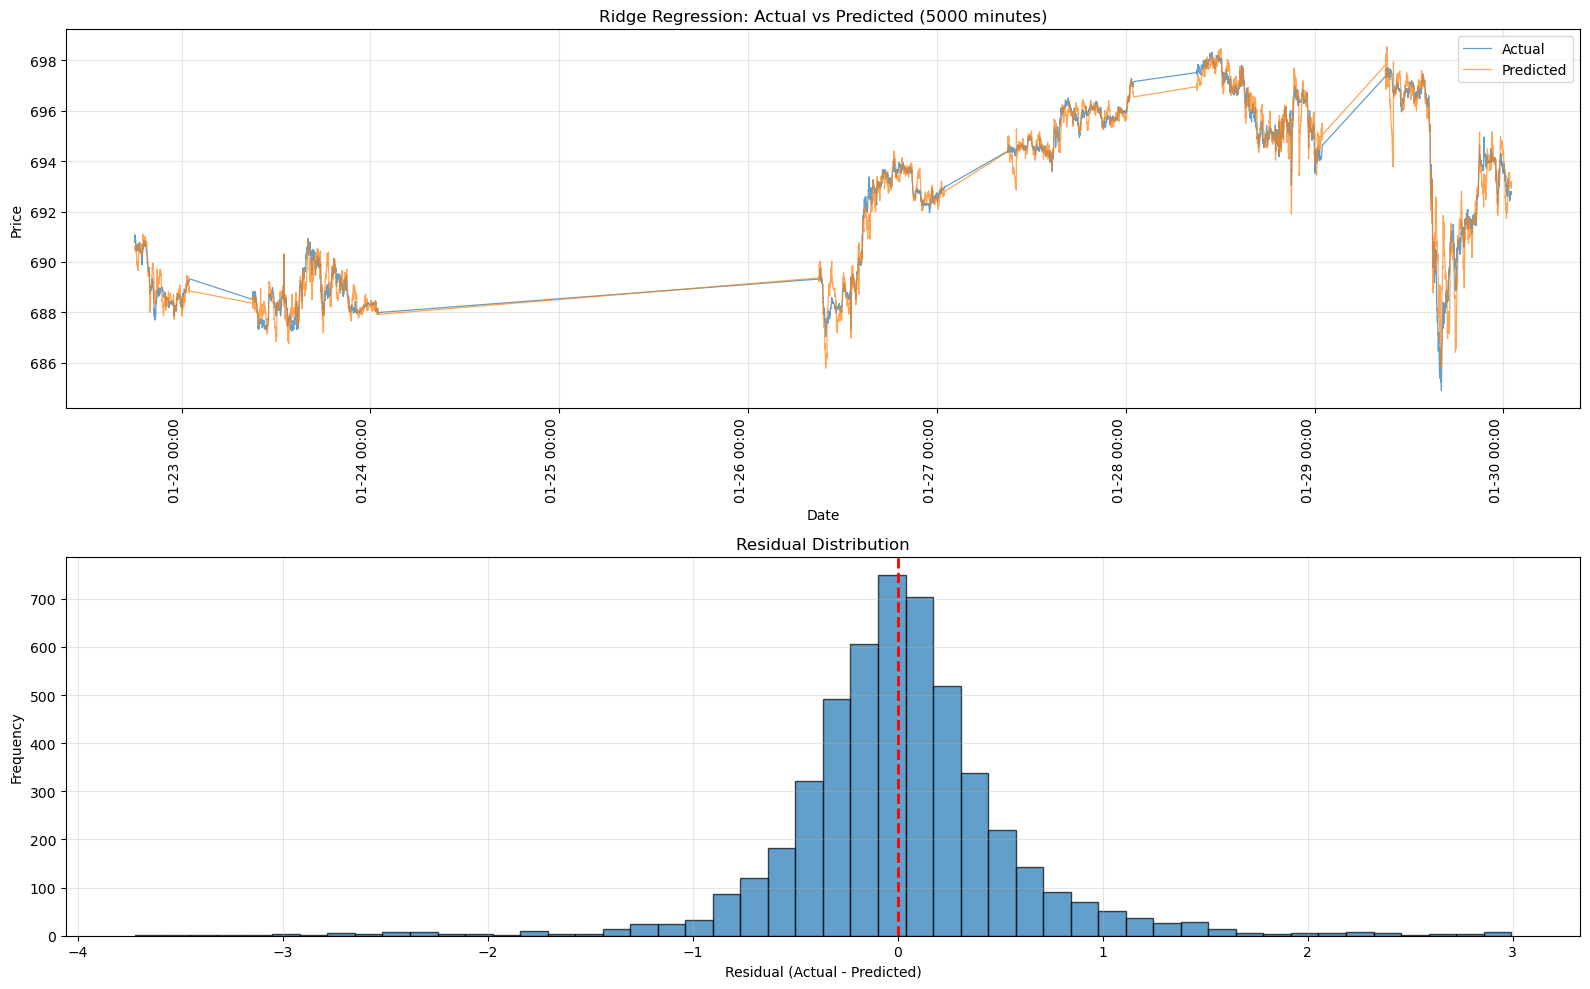


📊 Feature Coefficients (Ridge):
             Feature  Coefficient
         Open_lag_60    17.356792
     Price_vs_SMA_60     1.285663
        Stochastic_K    -0.151178
       Return_lag_60     0.123391
              Return    -0.076770
        Return_lag_1    -0.060264
        Return_lag_5    -0.051727
       Volatility_30    -0.036775
      Price_Position     0.034974
       Return_lag_15    -0.034064
 Volatility_5_lag_15    -0.031404
       Return_lag_30     0.028860
       Volume_SMA_20    -0.025919
  Volatility_5_lag_5    -0.014422
              Volume     0.013048
        Volume_lag_1     0.010477
        Volume_lag_5     0.007140
High_Low_Range_lag_5     0.006848
  Volatility_5_lag_1    -0.006453
       Volume_lag_15    -0.004841
        Volume_Ratio    -0.003452
      High_Low_Range    -0.002780
 Volume_change_lag_1    -0.001517
High_Low_Range_lag_1     0.001065
       Volume_change    -0.000753


In [97]:
# =============================================================================
# FINAL MODEL EVALUATION
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Use the best model for final evaluation
# Train on all but the last N samples, test on the last N
# 3 trading days ≈ 390 min/day × 3 = 1170 minutes, but user set 2500
holdout_size = 5000

X_train_final = X[:-holdout_size]
X_test_final = X[-holdout_size:]
y_train_final = y[:-holdout_size]
y_test_final = y[-holdout_size:]

# Get the dates for the test set
test_dates = df_model.index[-holdout_size:]

# Scale
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

# Train best model (based on results)
if best_model_name == 'Ridge Regression':
    best_model = Ridge(alpha=1.0)
elif best_model_name == 'Random Forest':
    best_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
elif best_model_name == 'XGBoost' and use_xgboost:
    from xgboost import XGBRegressor
    best_model = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, verbosity=0)
else:
    best_model = GradientBoostingRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)

best_model.fit(X_train_scaled, y_train_final)
y_pred_final = best_model.predict(X_test_scaled)

# Final metrics
final_rmse = np.sqrt(mean_squared_error(y_test_final, y_pred_final))
final_mae = mean_absolute_error(y_test_final, y_pred_final)
final_r2 = r2_score(y_test_final, y_pred_final)

print("=" * 60)
print(f"FINAL MODEL EVALUATION ({best_model_name})")
print("=" * 60)
print(f"\n📊 Holdout Set Performance (last {holdout_size} minutes):")
print(f"   RMSE: ${final_rmse:.4f}")
print(f"   MAE:  ${final_mae:.4f}")
print(f"   R²:   {final_r2:.4f}")

# Visualization - stacked vertically for better readability with large holdout
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: Actual vs Predicted with dates on x-axis
axes[0].plot(test_dates, y_test_final, label='Actual', alpha=0.7, linewidth=0.9)
axes[0].plot(test_dates, y_pred_final, label='Predicted', alpha=0.7, linewidth=0.9)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price')
axes[0].set_title(f'{best_model_name}: Actual vs Predicted ({holdout_size} minutes)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Format x-axis dates
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
axes[0].xaxis.set_major_locator(mdates.AutoDateLocator())
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=90, ha='right')

# Plot 2: Residuals
residuals = y_test_final - y_pred_final
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Feature importance (if available)
if hasattr(best_model, 'feature_importances_'):
    print("\n📊 Feature Importance:")
    importance_df = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    print(importance_df.to_string(index=False))
elif hasattr(best_model, 'coef_'):
    print("\n📊 Feature Coefficients (Ridge):")
    coef_df = pd.DataFrame({
        'Feature': feature_columns,
        'Coefficient': best_model.coef_
    }).sort_values('Coefficient', key=abs, ascending=False)
    print(coef_df.to_string(index=False))